Investigating the role of autapses in bursting activity.

In [1]:
"""
Take autapse params from Yin et al. 2018 and Pan et al. 2025 for excitatory autapse

Yin et al. 2018: f ~ 150 pA [27-430pA]
                 decay time constant = 4.6 ms
                 => e ~ 0.217
                 onset time 2ms, rise time 1ms 
                 => tau ~ 2-3ms?

Pan et al. 2025: f ~ 130 +- 16 pA
                 e ~ 0.182 +- 0.2 Hz

                
For inhibitory autapse see Deleuze et al. 2019 (PV interneurons), Bacci & Huguenard 2003
                 f ~ -451 +- 43
                 e ~ 0.27 +- 0.1
Bacci et al. 2003:
                 f ~ -352 +- 71 pA
                 e ~ 0.14 +- 0.03 Hz
                 latency ~ 1.76 +- 0.07 ms; rise time ~ 0.56 ms
                 tau ~ 2 ms
"""

'\nTake autapse params from Yin et al. 2018 and Pan et al. 2025 for excitatory autapse\n\nYin et al. 2018: f ~ 150 pA [27-430pA]\n                 decay time constant = 4.6 ms\n                 => e ~ 0.217\n                 onset time 2ms, rise time 1ms \n                 => tau ~ 2-3ms?\n\nPan et al. 2025: f ~ 130 +- 16 pA\n                 e ~ 0.182 +- 0.2 Hz\n\n\nFor inhibitory autapse see Deleuze et al. 2019 (PV interneurons), Bacci & Huguenard 2003\n                 f ~ -451 +- 43\n                 e ~ 0.27 +- 0.1\nBacci et al. 2003:\n                 f ~ -352 +- 71 pA\n                 e ~ 0.14 +- 0.03 Hz\n                 latency ~ 1.76 +- 0.07 ms; rise time ~ 0.56 ms\n                 tau ~ 2 ms\n'

#### Results

Differing results between both models. Additionally these change depending on the height of the current step. 

@ 75 pA step current.
Excitatory autapse seems to increase the chaotic activity of the neuron slightly. 
Inhibitory autapse doesn't seem to make a huge difference.


@ 100 pA step current.

For the excitatory autapse on a pyramidal cell, the autapse seems to significantly increase the chaotic activity of the neuron. 
Conversely, the inhibitory autapse on an FS neuron seems to stabilise the chaotic activity.

In [2]:
import sys
sys.path.append("..\\") # parent directory
from AQUA_general import AQUA
from batchAQUA_general import batchAQUA
from stimulus import *
from plotting_functions import *
from phase_response import *


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Excitatory Autapse on a model Pyramidal Neuron

In [3]:
# regular spiking neuron
RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

Time = 20  #ms
dt = 0.01 # ms
N_iter = int(1000*Time/dt)

x_ini = np.array([-80, 0, 0])
t_ini = 0.0

N_neurons = 1
f_range = np.linspace(30, 30, N_neurons)

#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(RS)
    x_start[n, :] = x_ini
    t_start[n] = t_ini

amp = 10
phase = 0
I_h = 75
I_inj = np.array([sinusoid(N_iter, dt, f, amp, phase)[0] + I_h for f in f_range])
print(np.shape(I_inj))

batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X_e, T, spikes_e = batch.update_batch(dt, N_iter, I_inj)



(1, 2000000)


100%|██████████| 1999999/1999999 [07:11<00:00, 4635.96it/s]


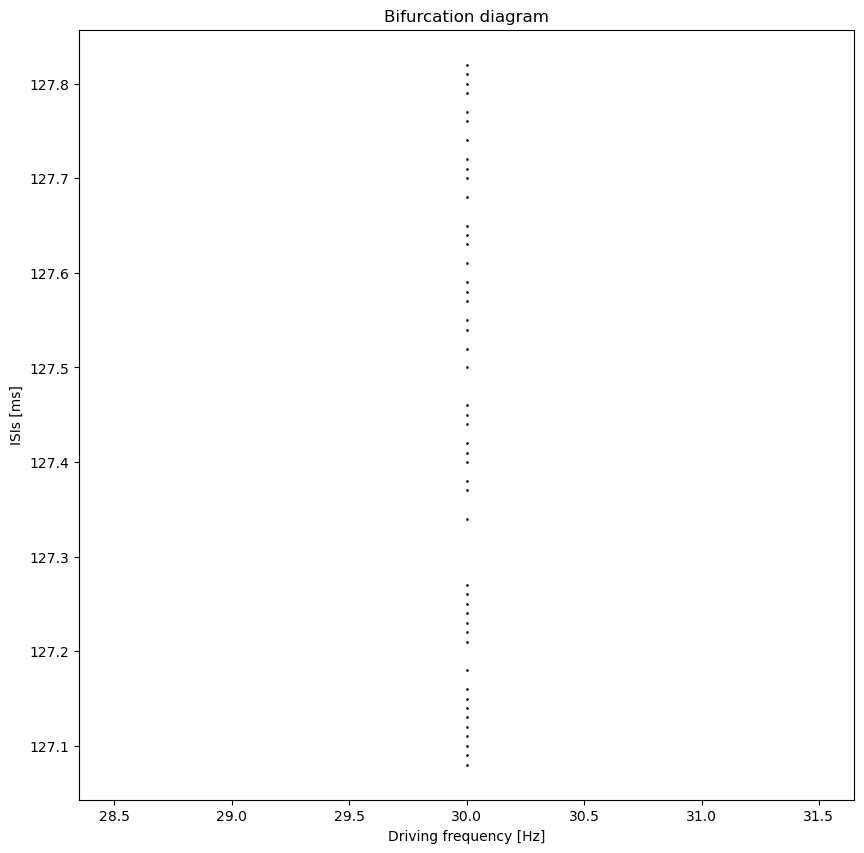

In [4]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_f(spikes_e, f_range, steady_state = True)
plt.savefig(f".\\bifurcations_f\\pyr_naut_steady{I_h}.png")
plt.show()

In [5]:
# regular spiking neuron
# autapse params described in intro.
RS_a = {'name': 'RS_a', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150.0, 'tau': 2.0}


#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(RS_a)
    x_start[n, :] = x_ini
    t_start[n] = t_ini


batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X_ea, _, spikes_ea = batch.update_batch(dt, N_iter, I_inj)

  0%|          | 0/1999999 [00:00<?, ?it/s]

100%|██████████| 1999999/1999999 [07:10<00:00, 4643.42it/s]


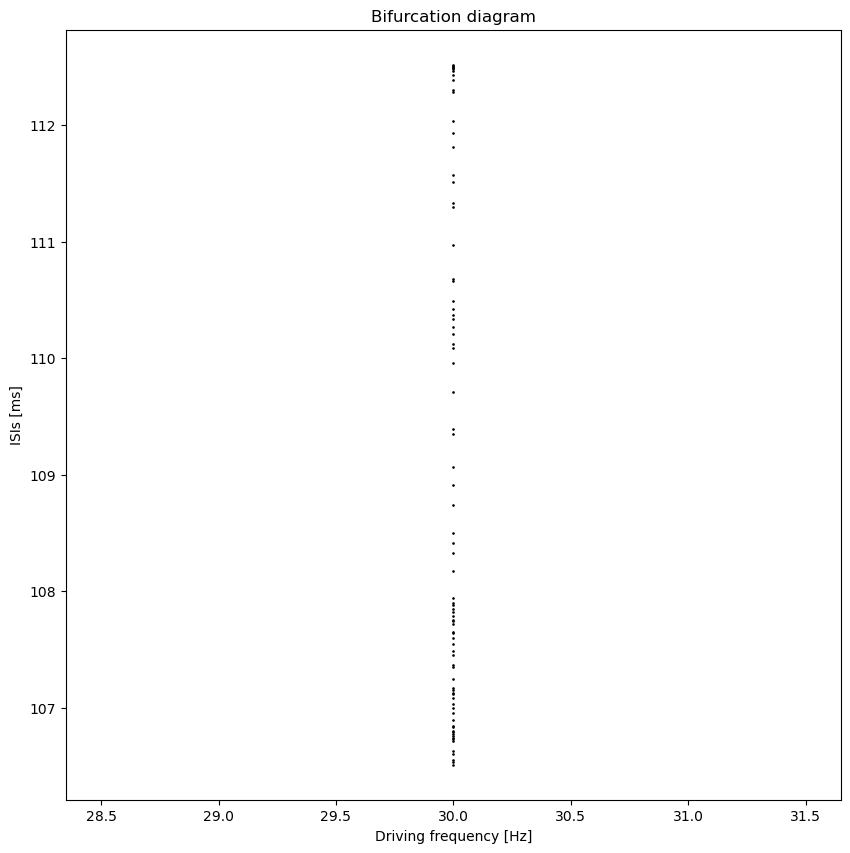

In [6]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_f(spikes_ea, f_range, steady_state = True)
plt.savefig(f".\\bifurcations_f\\pyr_aut_steady{I_h}.png")
plt.show()

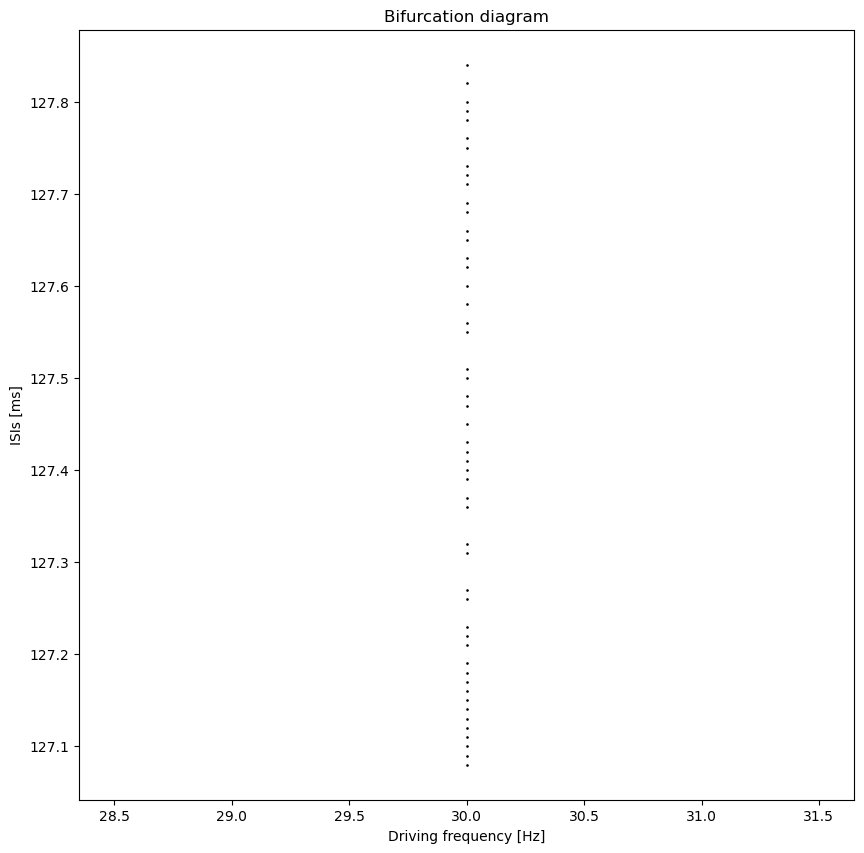

In [7]:
# plot the bifurcation diagram of instantaneous ISIs from normal neuron
fig, ax = plot_bifurcation_f(spikes_e, f_range, steady_state = False)
plt.savefig(f".\\bifurcations_f\\pyr_naut_instant{I_h}.png")
plt.show()

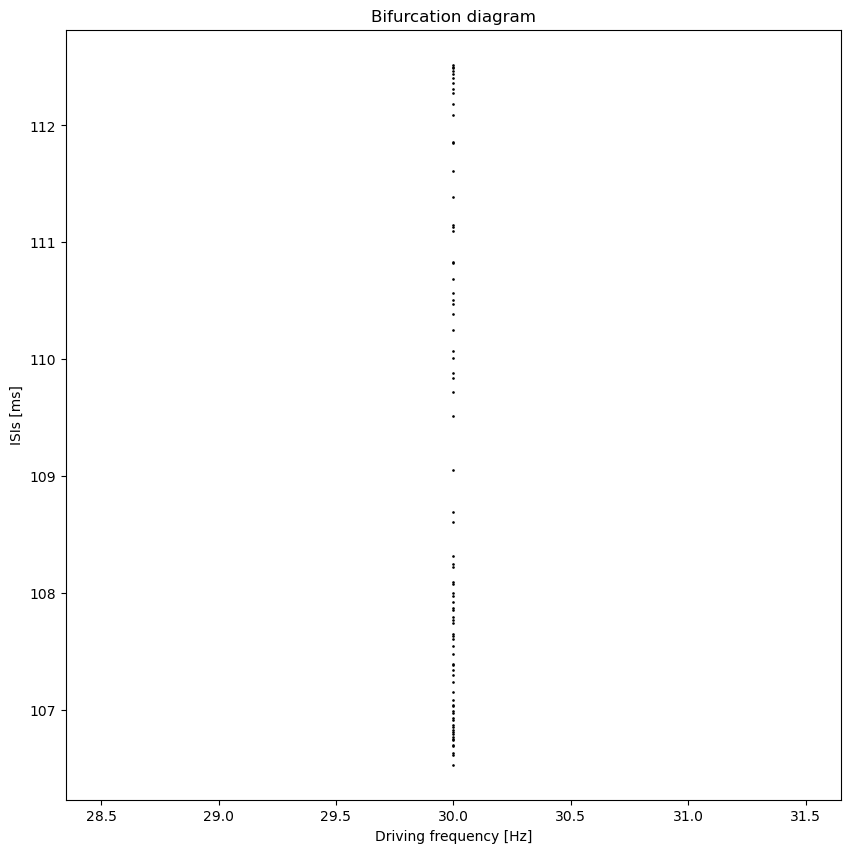

In [8]:
# plot the bifurcation diagram of instantaneous ISIs from autaptic neuron
fig, ax = plot_bifurcation_f(spikes_ea, f_range, steady_state = False)
plt.savefig(f".\\bifurcations_f\\pyr_aut_instant{I_h}.png")
plt.show()

30.0


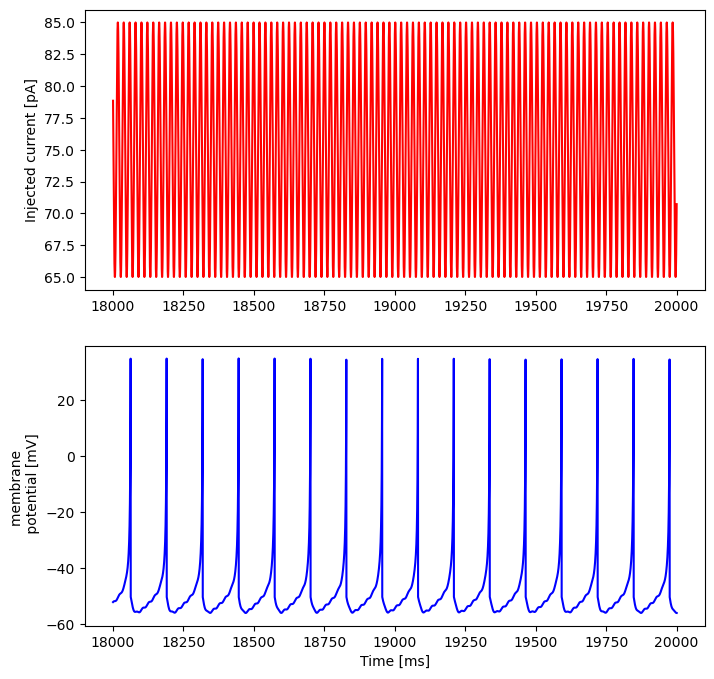

In [16]:
## Non-autaptic neuron
num = 0
print(f_range[num])
split = np.arange(1800000, 2000000)
fig, ax = plot_potential_versus_injected(X_e[num, :], T[:], I_inj[num, :], split)
plt.show()

30.0


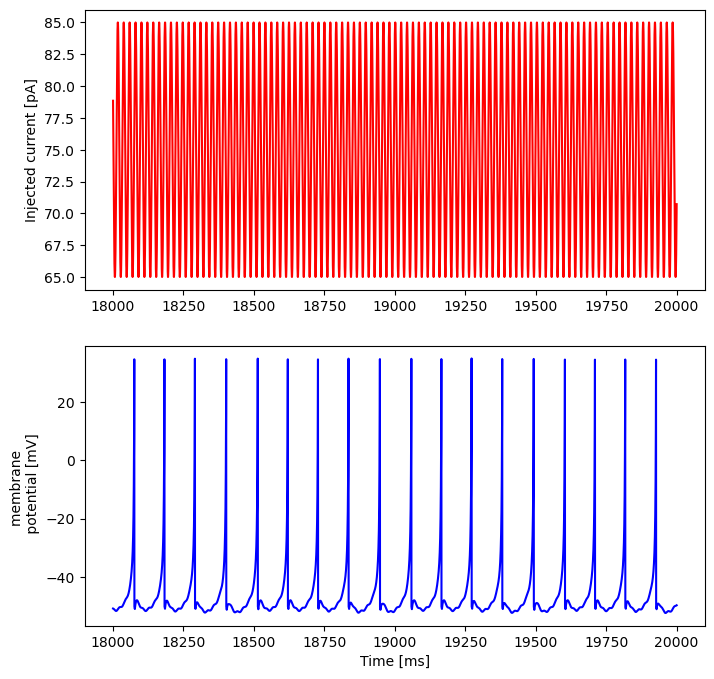

In [17]:
## autaptic neuron
num = 0
print(f_range[num])
fig, ax = plot_potential_versus_injected(X_ea[num, :], T[:], I_inj[num, :], split)
plt.show()

30.0


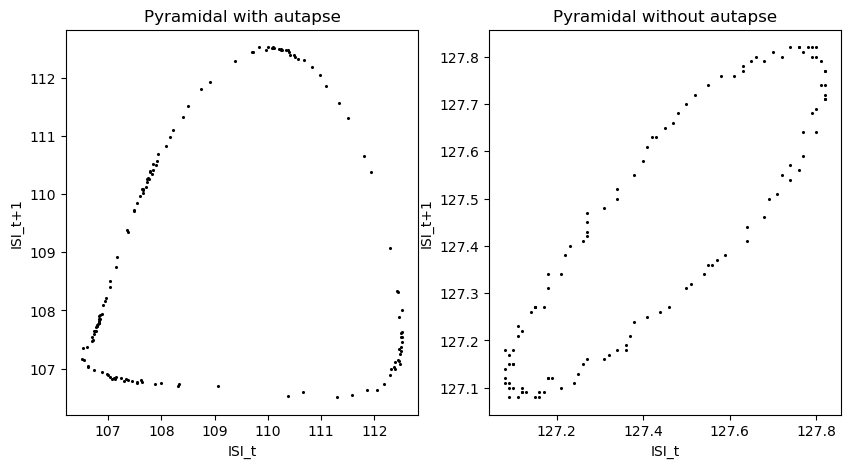

In [11]:
num = 0
print(f_range[num])
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
fig, ax[0] = first_return(spikes_ea[num, int(len(spikes_ea[num, :])/5):], fig, ax[0])
fig, ax[1] = first_return(spikes_e[num, int(len(spikes_ea[num, :])/5):], fig, ax[1])

ax[0].set_title("Pyramidal with autapse")
ax[1].set_title("Pyramidal without autapse")
plt.show()

Initial results show that the autapse on the excitatory neuron model has little effect on the long-term activity of the neuron. However, there is a noticeable complication of the instantaneous activity

### Inhibitory Autapse on a model Fast-spiking interneuron

In [ ]:
# fast-spiking interneuron
FS = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

#N_neurons = 300
#f_range = np.linspace(0, 50, N_neurons)

#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(FS)
    x_start[n, :] = x_ini
    t_start[n] = t_ini


I_inj = np.array([sinusoid(N_iter, dt, f, amp, phase)[0] + I_h for f in f_range])
print(np.shape(I_inj))

batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X_i, _, spikes_i = batch.update_batch(dt, N_iter, I_inj)

(200, 400000)


100%|██████████| 399999/399999 [01:27<00:00, 4571.88it/s]


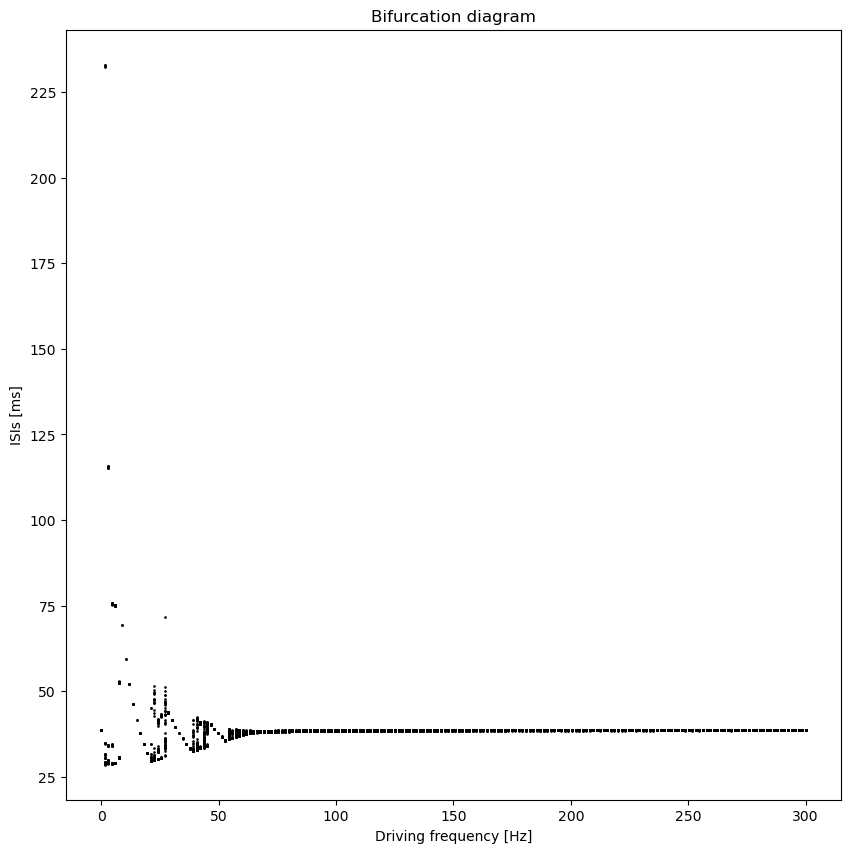

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_f(spikes_i, f_range, steady_state = True)
plt.savefig(f".\\bifurcations_f\\fs_naut_steady{I_h}.png")
plt.show()

In [ ]:
# fast-spiking interneuron
# autapse from Bacci 2003
FS_a = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.14, 'f': -350.0, 'tau': 2.0}


#define initial conditions
params = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)
for n in range(N_neurons):
    params.append(FS_a)
    x_start[n, :] = x_ini
    t_start[n] = t_ini



batch = batchAQUA(params)

batch.Initialise(x_start, t_start)

X_ia, T, spikes_ia = batch.update_batch(dt, N_iter, I_inj)

100%|██████████| 399999/399999 [01:23<00:00, 4778.27it/s]


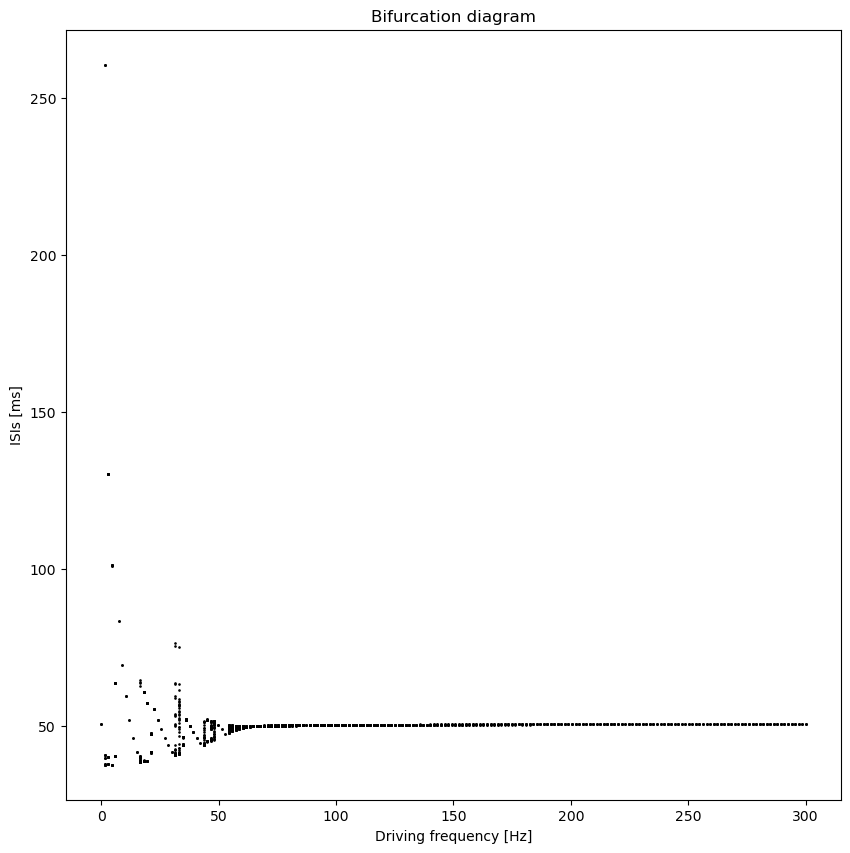

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_f(spikes_ia, f_range, steady_state = True)
plt.savefig(f".\\bifurcations_f\\fs_aut_steady{I_h}.png")
plt.show()

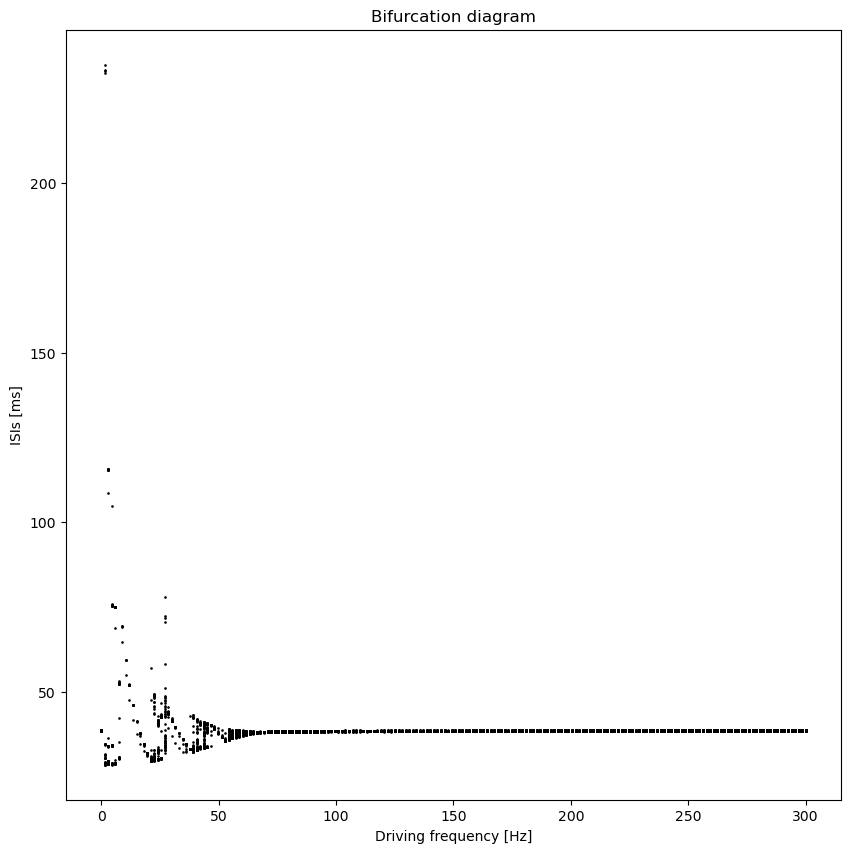

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_f(spikes_i, f_range, steady_state = False)
plt.savefig(f".\\bifurcations_f\\fs_naut_instant{I_h}.png")
plt.show()

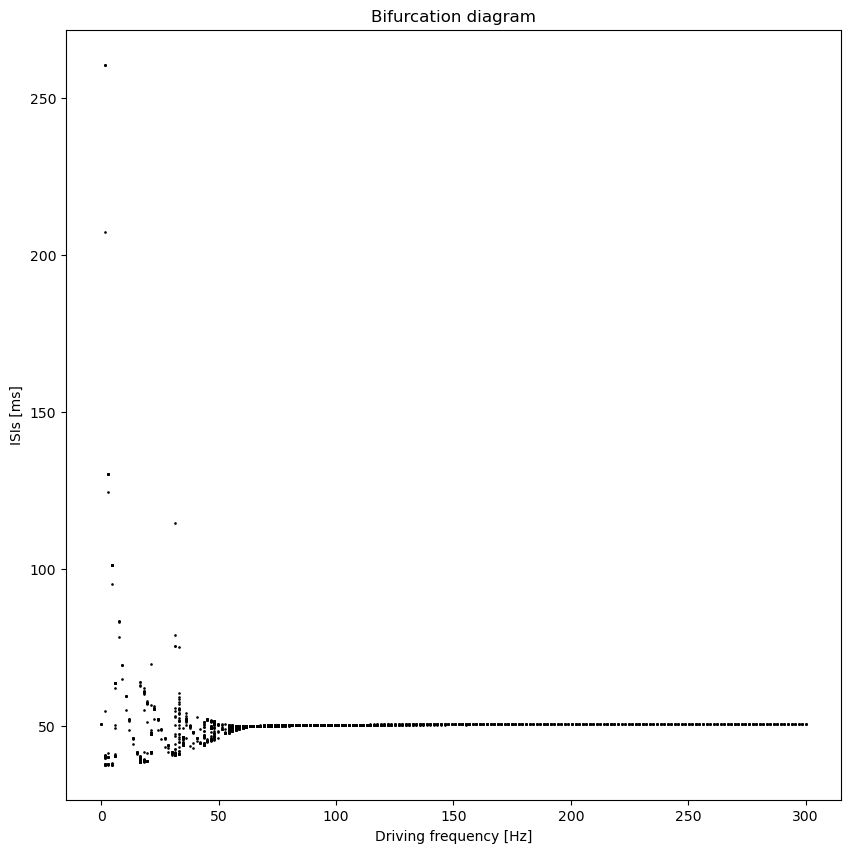

In [ ]:
# plot the bifurcation diagram
fig, ax = plot_bifurcation_f(spikes_ia, f_range, steady_state = False)
plt.savefig(f".\\bifurcations_f\\fs_aut_instant{I_h}.png")
plt.show()

60.301507537688444


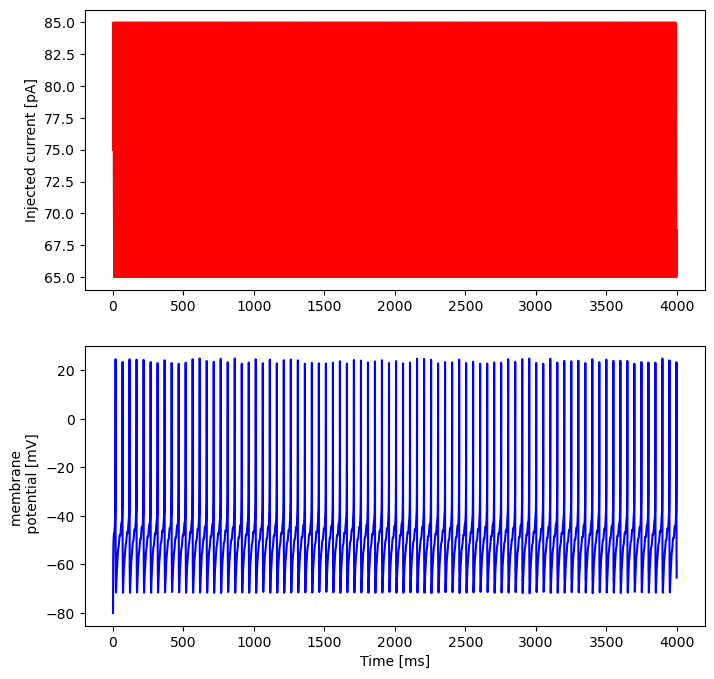

In [ ]:
num = 40
print(f_range[num])
fig, ax = plot_potential_versus_injected(X_ia[num, :], T[:], I_inj[num, :])
plt.show()

60.301507537688444


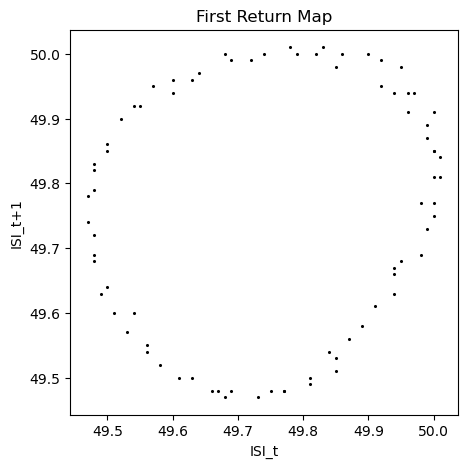

In [ ]:
num = 40
print(f_range[num])
fig, ax = plt.subplots(1, 1, figsize = (5, 5))
fig, ax = first_return(spikes_ia[num, :], fig, ax)

plt.show()

In [18]:
num = 37
print(f_range[num])
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
fig, ax[0] = first_return(spikes_ia[num, :], fig, ax[0])
fig, ax[1] = first_return(spikes_i[num, :], fig, ax[1])

ax[0].set_title("FS neurons with autapse")
ax[1].set_title("FS neuron without autapse")
plt.show()

IndexError: index 37 is out of bounds for axis 0 with size 1

226.13065326633168


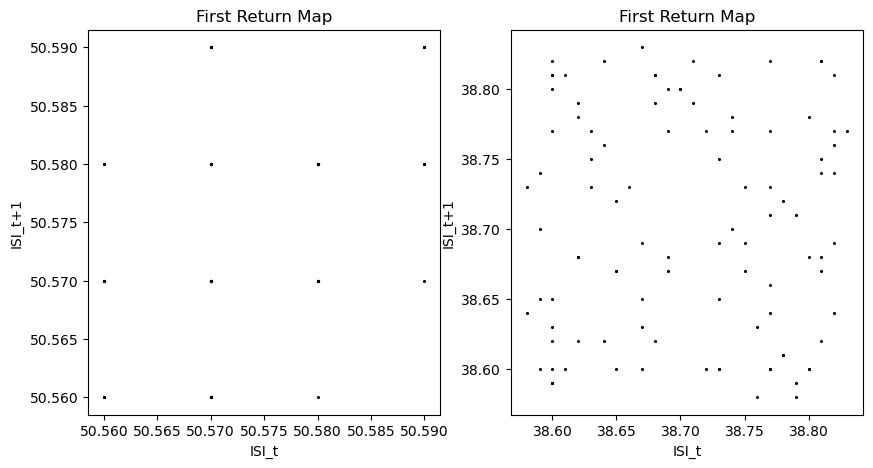

In [ ]:
num = 150
print(f_range[num])
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
fig, ax[0] = first_return(spikes_ia[num, :], fig, ax[0])
fig, ax[1] = first_return(spikes_i[num, :], fig, ax[1])
plt.show()